In [1]:
import pandas as pd
from scipy.stats import spearmanr

df = pd.read_csv("replicon_pair_homology_full.tsv", sep="\t")

# nos quedamos solo con pares válidos
df = df.dropna(subset=["cointegration_rate"])


In [2]:
homology_metrics = [
    # bp crudos
    "mean_bp",
    "median_bp",
    "max_bp",
    "sum_bp",
    "p_bp_gt_500",
    "p_bp_gt_1000",
    "p_bp_gt_5000",
    "p_bp_gt_10000",

    # coverage
    "mean_cov",
    "median_cov",
    "max_cov",
    "p_cov_gt_001",
    "p_cov_gt_01",
    "p_cov_gt_05",
]


In [3]:
results = []

for m in homology_metrics:
    sub = df[["cointegration_rate", m]].dropna()
    if len(sub) < 5:
        continue

    rho, p = spearmanr(sub["cointegration_rate"], sub[m])
    results.append({
        "metric": m,
        "spearman_rho": rho,
        "p_value": p,
        "n_pairs": len(sub)
    })

corr = pd.DataFrame(results).sort_values(
    by="spearman_rho", ascending=False
)

print(corr)


           metric  spearman_rho       p_value  n_pairs
10        max_cov      0.299819  7.901077e-34     1563
3          sum_bp      0.255307  1.113948e-24     1563
2          max_bp      0.243340  1.675715e-22     1563
8        mean_cov      0.232650  1.179077e-20     1563
13    p_cov_gt_05      0.226752  1.127432e-19     1563
9      median_cov      0.201835  7.872394e-16     1563
6    p_bp_gt_5000      0.201785  8.005090e-16     1563
7   p_bp_gt_10000      0.199723  1.584992e-15     1563
0         mean_bp      0.179677  8.298684e-13     1563
1       median_bp      0.153099  1.173752e-09     1563
12    p_cov_gt_01      0.132901  1.339046e-07     1563
5    p_bp_gt_1000      0.092579  2.472861e-04     1563
4     p_bp_gt_500      0.031319  2.158974e-01     1563
11   p_cov_gt_001     -0.015247  5.469350e-01     1563


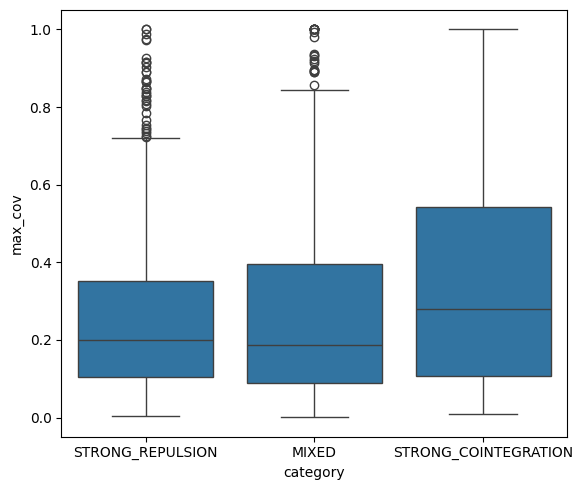

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

best = corr.iloc[0]["metric"]

plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y=best,
    order=["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]
)
plt.ylabel(best)
plt.tight_layout()
plt.show()


=== Spearman correlations ===
p_bp_gt_1000     | rho = 0.093 | p = 2.47e-04
log10(mean_bp)  | rho = 0.180 | p = 8.30e-13


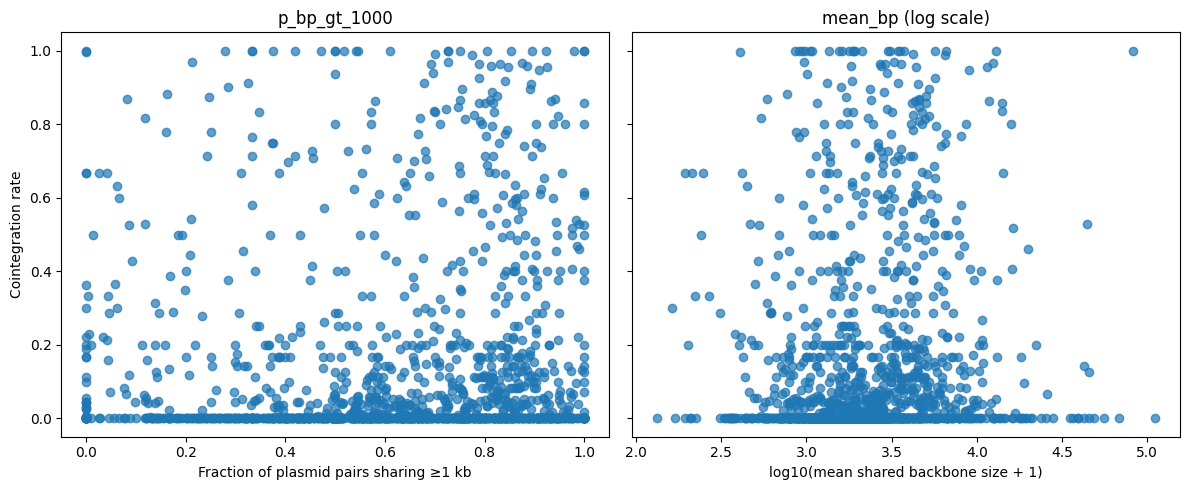

In [10]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
df = pd.read_csv(
    "replicon_pair_homology_full.tsv",
    sep="\t"
)

df = df.dropna(subset=["cointegration_rate"])

# evitar log(0)
df["mean_bp_log10"] = np.log10(df["mean_bp"] + 1)

# --------------------------------------------------
# 2. CORRELACIONES (SPEARMAN)
# --------------------------------------------------
print("=== Spearman correlations ===")

rho1, p1 = spearmanr(df["p_bp_gt_1000"], df["cointegration_rate"])
rho2, p2 = spearmanr(df["mean_bp_log10"], df["cointegration_rate"])

print(f"p_bp_gt_1000     | rho = {rho1:.3f} | p = {p1:.2e}")
print(f"log10(mean_bp)  | rho = {rho2:.3f} | p = {p2:.2e}")

# --------------------------------------------------
# 3. VISUALIZACIÓN
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# frecuencia ≥1 kb
axes[0].scatter(
    df["p_bp_gt_1000"],
    df["cointegration_rate"],
    alpha=0.7
)
axes[0].set_xlabel("Fraction of plasmid pairs sharing ≥1 kb")
axes[0].set_ylabel("Cointegration rate")
axes[0].set_title("p_bp_gt_1000")

# mean_bp en log
axes[1].scatter(
    df["mean_bp_log10"],
    df["cointegration_rate"],
    alpha=0.7
)
axes[1].set_xlabel("log10(mean shared backbone size + 1)")
axes[1].set_title("mean_bp (log scale)")

plt.tight_layout()
plt.show()


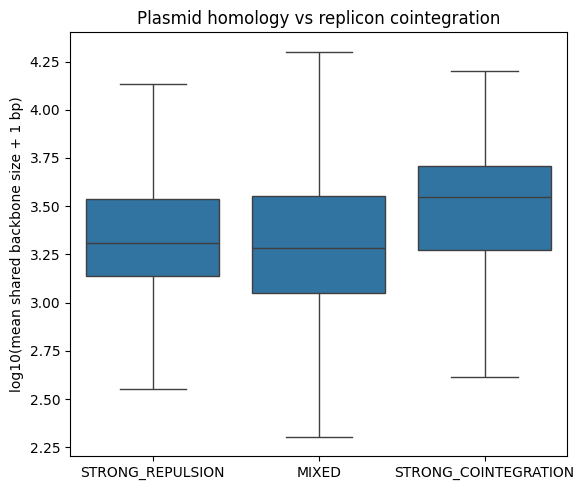

Mann–Whitney U test (STRONG_COINTEGRATION > STRONG_REPULSION): p = 5.87e-05


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
df = pd.read_csv(
    "replicon_pair_homology_full.tsv",
    sep="\t"
)

# quedarnos con filas válidas
df = df.dropna(subset=["mean_bp", "category"])

# log-transform (bp genómicos → log)
df["mean_bp_log10"] = np.log10(df["mean_bp"] + 1)

# --------------------------------------------------
# 2. BOXPLOT
# --------------------------------------------------
order = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y="mean_bp_log10",
    order=order,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("log10(mean shared backbone size + 1 bp)")
plt.title("Plasmid homology vs replicon cointegration")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. TEST ESTADÍSTICO (opcional pero recomendable)
# --------------------------------------------------
a = df[df.category=="STRONG_COINTEGRATION"]["mean_bp_log10"]
b = df[df.category=="STRONG_REPULSION"]["mean_bp_log10"]

u, p = mannwhitneyu(a, b, alternative="greater")
print(f"Mann–Whitney U test (STRONG_COINTEGRATION > STRONG_REPULSION): p = {p:.2e}")


In [3]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# --------------------------------------------------
# 4. TODAS LAS COMPARACIONES PAREADAS
# --------------------------------------------------

groups = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

results = []

def cliffs_delta(x, y):
    """
    Cliff's delta effect size
    """
    x = np.array(x)
    y = np.array(y)
    n_x = len(x)
    n_y = len(y)

    greater = 0
    lower = 0

    for xi in x:
        greater += np.sum(xi > y)
        lower   += np.sum(xi < y)

    delta = (greater - lower) / (n_x * n_y)
    return delta

for g1, g2 in combinations(groups, 2):
    
    x = df[df.category == g1]["mean_bp_log10"]
    y = df[df.category == g2]["mean_bp_log10"]

    # test bilateral
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    
    delta = cliffs_delta(x, y)

    results.append({
        "comparison": f"{g1} vs {g2}",
        "U_stat": u,
        "p_raw": p,
        "cliffs_delta": delta
    })

res_df = pd.DataFrame(results)

# --------------------------------------------------
# 5. CORRECCIÓN FDR
# --------------------------------------------------

res_df["p_FDR"] = multipletests(res_df["p_raw"], method="fdr_bh")[1]

print(res_df.sort_values("p_FDR"))

                                 comparison    U_stat     p_raw  cliffs_delta  \
2             MIXED vs STRONG_COINTEGRATION   13149.0  0.000040     -0.332199   
1  STRONG_REPULSION vs STRONG_COINTEGRATION   15022.0  0.000117     -0.310285   
0                 STRONG_REPULSION vs MIXED  299327.0  0.061495      0.055693   

      p_FDR  
2  0.000119  
1  0.000176  
0  0.061495  


In [13]:
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import mannwhitneyu

# --------------------------------------------------
# Cliff's delta (direccional y robusto)
# --------------------------------------------------
def cliffs_delta(x, y):
    """
    Cliff's delta: P(x > y) - P(x < y)
    > 0  -> x tends to be larger than y
    < 0  -> x tends to be smaller than y
    """
    nx = len(x)
    ny = len(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    delta = (2 * u) / (nx * ny) - 1
    return delta

# --------------------------------------------------
# Categories (orden lógico)
# --------------------------------------------------
categories = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

results = []

for c1, c2 in combinations(categories, 2):

    x = df[df.category == c1]["mean_bp_log10"]
    y = df[df.category == c2]["mean_bp_log10"]

    # Test direccional coherente con comparación
    u, p = mannwhitneyu(y, x, alternative="greater")

    delta = cliffs_delta(y, x)

    results.append({
        "comparison": f"{c2} > {c1}",
        f"n_{c1}": len(x),
        f"n_{c2}": len(y),
        "median_{}".format(c1): x.median(),
        "median_{}".format(c2): y.median(),
        "U_statistic": u,
        "p_value": p,
        "cliffs_delta": delta
    })

stats_df = pd.DataFrame(results)

print("\n=== Pairwise statistics (log10 mean_bp) ===")
print(stats_df)



=== Pairwise statistics (log10 mean_bp) ===
                                comparison  n_STRONG_REPULSION  n_MIXED  \
0                 MIXED > STRONG_REPULSION               792.0    716.0   
1  STRONG_COINTEGRATION > STRONG_REPULSION               792.0      NaN   
2             STRONG_COINTEGRATION > MIXED                 NaN    716.0   

   median_STRONG_REPULSION  median_MIXED  U_statistic   p_value  cliffs_delta  \
0                 3.310682      3.284641     267745.0  0.969261     -0.055693   
1                 3.310682           NaN      28538.0  0.000059      0.310285   
2                      NaN      3.284641      26231.0  0.000020      0.332199   

   n_STRONG_COINTEGRATION  median_STRONG_COINTEGRATION  
0                     NaN                          NaN  
1                    55.0                     3.548062  
2                    55.0                     3.548062  



=== Descriptive statistics (ultraconserved bp) ===
                        n    median      mean       q25       q75
category                                                         
STRONG_REPULSION      766  3.219585  3.222856  3.080626  3.395457
MIXED                 657  3.216166  3.168460  2.927883  3.443889
STRONG_COINTEGRATION   45  3.386142  3.328150  3.217089  3.509135


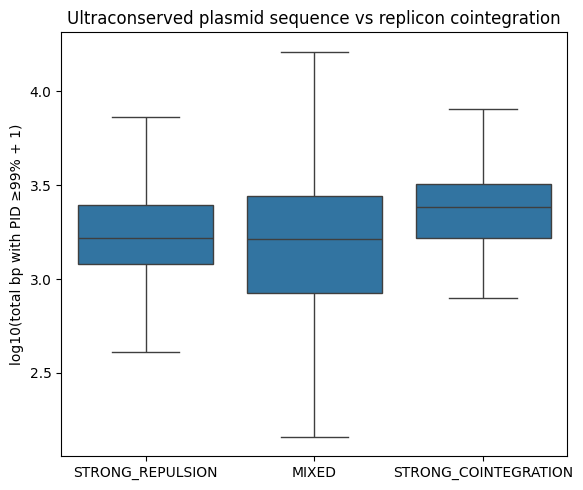


=== Pairwise comparisons ===
MIXED > STRONG_REPULSION | median MIXED=3.22, median STRONG_REPULSION=3.22, p=9.59e-01, Cliff's δ=-0.05
STRONG_COINTEGRATION > STRONG_REPULSION | median STRONG_COINTEGRATION=3.39, median STRONG_REPULSION=3.22, p=2.03e-03, Cliff's δ=0.25
STRONG_COINTEGRATION > MIXED | median STRONG_COINTEGRATION=3.39, median MIXED=3.22, p=2.31e-03, Cliff's δ=0.25


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing"

# --------------------------------------------------
# 1. LOAD COORDS
# --------------------------------------------------
coords = pd.read_csv(
    f"{BASE}/coords_all_hits.tsv",
    sep="\t"
)

coords = coords[[
    "replicon_pair",
    "plasmid_A",
    "plasmid_B",
    "start_A",
    "end_A",
    "aln_len_A",
    "pct_identity"
]]

# --------------------------------------------------
# 2. FILTER: ultraconserved fragments
# --------------------------------------------------
coords = coords[
    (coords["aln_len_A"] >= 50) &
    (coords["pct_identity"] >= 99.0)
]

# --------------------------------------------------
# 3. COLLAPSE OVERLAPS
# --------------------------------------------------
def collapse_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = []
    cs, ce = intervals[0]
    for s, e in intervals[1:]:
        if s <= ce:
            ce = max(ce, e)
        else:
            merged.append((cs, ce))
            cs, ce = s, e
    merged.append((cs, ce))
    return merged

rows = []

for (pair, A, B), sub in coords.groupby(
    ["replicon_pair", "plasmid_A", "plasmid_B"]
):
    intervals = list(zip(sub.start_A, sub.end_A))
    merged = collapse_intervals(intervals)
    total_bp = sum(e - s + 1 for s, e in merged)

    rows.append({
        "replicon_pair": pair,
        "plasmid_A": A,
        "plasmid_B": B,
        "ultraconserved_bp": total_bp
    })

plasm_uc = pd.DataFrame(rows)

# --------------------------------------------------
# 4. AGGREGATE TO REPLICON-PAIR
# --------------------------------------------------
rep_rows = []

for pair, sub in plasm_uc.groupby("replicon_pair"):
    rep_rows.append({
        "replicon_pair": pair,
        "n_plasmid_pairs": len(sub),
        "median_uc_bp": sub["ultraconserved_bp"].median(),
        "mean_uc_bp": sub["ultraconserved_bp"].mean(),
        "max_uc_bp": sub["ultraconserved_bp"].max(),
        "p_uc_gt_1kb": (sub["ultraconserved_bp"] >= 1000).mean()
    })

uc_rep = pd.DataFrame(rep_rows)
uc_rep[["repA", "repB"]] = uc_rep["replicon_pair"].str.split("__", expand=True)

# --------------------------------------------------
# 5. MERGE WITH COINTEGRATION
# --------------------------------------------------
coin = pd.read_csv(f"{BASE}/pairs_table.csv")

df = uc_rep.merge(
    coin,
    on=["repA", "repB"],
    how="left"
)

df = df.dropna(subset=["category", "median_uc_bp"])

# --------------------------------------------------
# 6. STATISTICS + BOXPLOT
# --------------------------------------------------
df["log_median_uc_bp"] = np.log10(df["median_uc_bp"] + 1)

order = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

# Descriptiva
summary = (
    df.groupby("category")["log_median_uc_bp"]
      .agg(
          n="count",
          median="median",
          mean="mean",
          q25=lambda x: x.quantile(0.25),
          q75=lambda x: x.quantile(0.75)
      )
      .loc[order]
)

print("\n=== Descriptive statistics (ultraconserved bp) ===")
print(summary)

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y="log_median_uc_bp",
    order=order,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("log10(total bp with PID ≥99% + 1)")
plt.title("Ultraconserved plasmid sequence vs replicon cointegration")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. PAIRWISE TESTS
# --------------------------------------------------
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u) / (nx * ny) - 1

print("\n=== Pairwise comparisons ===")

for c1, c2 in combinations(order, 2):
    x = df[df.category == c1]["log_median_uc_bp"]
    y = df[df.category == c2]["log_median_uc_bp"]

    u, p = mannwhitneyu(y, x, alternative="greater")
    delta = cliffs_delta(y, x)

    print(
        f"{c2} > {c1} | "
        f"median {c2}={y.median():.2f}, "
        f"median {c1}={x.median():.2f}, "
        f"p={p:.2e}, "
        f"Cliff's δ={delta:.2f}"
    )


/tmp/ipykernel_2552568/21848628.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


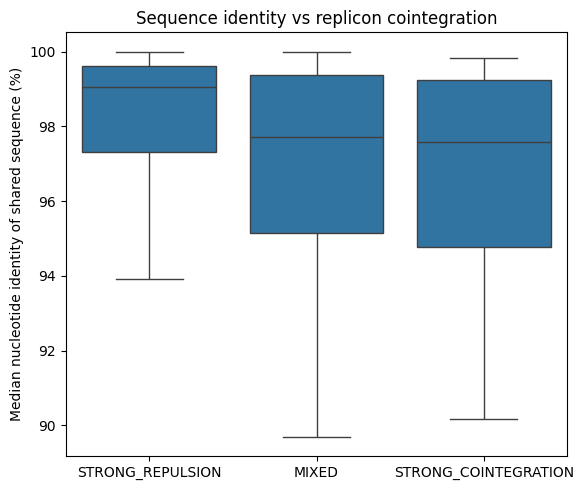


=== Pairwise Mann–Whitney tests (PID) ===
MIXED > STRONG_REPULSION: median MIXED=97.72, median STRONG_REPULSION=99.04, p=1.00e+00, Cliff's δ=-0.25
STRONG_COINTEGRATION > STRONG_REPULSION: median STRONG_COINTEGRATION=97.58, median STRONG_REPULSION=99.04, p=1.00e+00, Cliff's δ=-0.29
STRONG_COINTEGRATION > MIXED: median STRONG_COINTEGRATION=97.58, median MIXED=97.72, p=6.83e-01, Cliff's δ=-0.04


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing"

# --------------------------------------------------
# 1. LOAD COORDS
# --------------------------------------------------
coords = pd.read_csv(
    f"{BASE}/coords_all_hits.tsv",
    sep="\t"
)

coords = coords[[
    "replicon_pair",
    "plasmid_A",
    "plasmid_B",
    "aln_len_A",
    "pct_identity"
]]

# --------------------------------------------------
# 2. PID PONDERADO POR BP (PAR DE PLÁSMIDOS)
# --------------------------------------------------
plasm_pid = (
    coords
    .groupby(["replicon_pair", "plasmid_A", "plasmid_B"])
    .apply(
        lambda x: np.average(
            x["pct_identity"],
            weights=x["aln_len_A"]
        )
    )
    .reset_index(name="pid_all_bp")
)

# --------------------------------------------------
# 3. AGREGATE TO REPLICON PAIR
# --------------------------------------------------
rep_pid = (
    plasm_pid
    .groupby("replicon_pair")["pid_all_bp"]
    .median()
    .reset_index(name="median_pid_all_bp")
)

rep_pid[["repA", "repB"]] = rep_pid["replicon_pair"].str.split("__", expand=True)

# --------------------------------------------------
# 4. MERGE WITH COINTEGRATION
# --------------------------------------------------
coin = pd.read_csv(f"{BASE}/pairs_table.csv")

df = rep_pid.merge(
    coin,
    on=["repA", "repB"],
    how="left"
)

df = df.dropna(subset=["category", "median_pid_all_bp"])

# --------------------------------------------------
# 5. BOXPLOT
# --------------------------------------------------
order = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y="median_pid_all_bp",
    order=order,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("Median nucleotide identity of shared sequence (%)")
plt.title("Sequence identity vs replicon cointegration")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. PAIRWISE STATS
# --------------------------------------------------
print("\n=== Pairwise Mann–Whitney tests (PID) ===")

def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u) / (nx * ny) - 1

for c1, c2 in combinations(order, 2):
    x = df[df.category == c1]["median_pid_all_bp"]
    y = df[df.category == c2]["median_pid_all_bp"]

    u, p = mannwhitneyu(y, x, alternative="greater")
    delta = cliffs_delta(y, x)

    print(
        f"{c2} > {c1}: "
        f"median {c2}={y.median():.2f}, "
        f"median {c1}={x.median():.2f}, "
        f"p={p:.2e}, "
        f"Cliff's δ={delta:.2f}"
    )


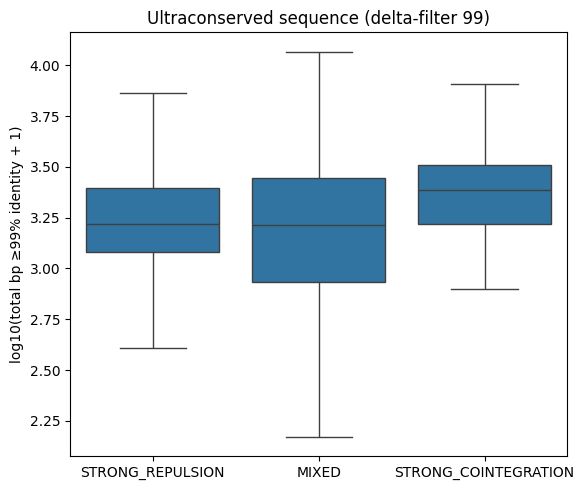


=== Pairwise tests (delta99) ===
MIXED > STRONG_REPULSION | median MIXED=3.22, median STRONG_REPULSION=3.22, p=9.60e-01, Cliff's δ=-0.05
STRONG_COINTEGRATION > STRONG_REPULSION | median STRONG_COINTEGRATION=3.39, median STRONG_REPULSION=3.22, p=1.81e-03, Cliff's δ=0.26
STRONG_COINTEGRATION > MIXED | median STRONG_COINTEGRATION=3.39, median MIXED=3.22, p=2.03e-03, Cliff's δ=0.26


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/cell_level/homology_sharing"

# --------------------------------------------------
# 1. LOAD DELTA99 HITS
# --------------------------------------------------
coords = pd.read_csv(
    f"{BASE}/coords99_all_hits.tsv",
    sep="\t"
)

coords = coords[[
    "replicon_pair",
    "plasmid_A",
    "plasmid_B",
    "start_A",
    "end_A"
]]

# --------------------------------------------------
# 2. COLLAPSE OVERLAPS
# --------------------------------------------------
def collapse(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = []
    cs, ce = intervals[0]
    for s, e in intervals[1:]:
        if s <= ce:
            ce = max(ce, e)
        else:
            merged.append((cs, ce))
            cs, ce = s, e
    merged.append((cs, ce))
    return merged

rows = []

for (pair, A, B), sub in coords.groupby(
    ["replicon_pair", "plasmid_A", "plasmid_B"]
):
    intervals = list(zip(sub.start_A, sub.end_A))
    merged = collapse(intervals)
    total_bp = sum(e - s + 1 for s, e in merged)

    rows.append({
        "replicon_pair": pair,
        "plasmid_A": A,
        "plasmid_B": B,
        "ultra_bp": total_bp
    })

plasm = pd.DataFrame(rows)

# --------------------------------------------------
# 3. AGGREGATE TO REPLICON PAIR
# --------------------------------------------------
rep = (
    plasm
    .groupby("replicon_pair")["ultra_bp"]
    .median()
    .reset_index(name="median_ultra_bp")
)

rep[["repA", "repB"]] = rep["replicon_pair"].str.split("__", expand=True)

# --------------------------------------------------
# 4. MERGE WITH COINTEGRATION
# --------------------------------------------------
coin = pd.read_csv(f"{BASE}/pairs_table.csv")

df = rep.merge(
    coin,
    on=["repA", "repB"],
    how="left"
)

df = df.dropna(subset=["category"])

df["log_ultra_bp"] = np.log10(df["median_ultra_bp"] + 1)

# --------------------------------------------------
# 5. BOXPLOT
# --------------------------------------------------
order = ["STRONG_REPULSION", "MIXED", "STRONG_COINTEGRATION"]

plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="category",
    y="log_ultra_bp",
    order=order,
    showfliers=False
)

plt.ylabel("log10(total bp ≥99% identity + 1)")
plt.xlabel("")
plt.title("Ultraconserved sequence (delta-filter 99)")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. STATS
# --------------------------------------------------
print("\n=== Pairwise tests (delta99) ===")

def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2 * u) / (nx * ny) - 1

for c1, c2 in combinations(order, 2):
    x = df[df.category == c1]["log_ultra_bp"]
    y = df[df.category == c2]["log_ultra_bp"]

    u, p = mannwhitneyu(y, x, alternative="greater")
    delta = cliffs_delta(y, x)

    print(
        f"{c2} > {c1} | "
        f"median {c2}={y.median():.2f}, "
        f"median {c1}={x.median():.2f}, "
        f"p={p:.2e}, "
        f"Cliff's δ={delta:.2f}"
    )
